In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [43]:
df = pd.read_csv(r"C:\Users\adity\Downloads\Dyashin Technosoft DS Internship\Datasets\winequality-white.csv", sep=';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [44]:
df.shape

(4898, 12)

In [45]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [46]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [47]:
df.duplicated().sum()

937

In [48]:
df = df.drop_duplicates()

In [49]:
from sklearn.model_selection import train_test_split

X = df.drop("quality", axis=1)
y = df["quality"].apply(lambda x: 1 if x >= 7 else 0) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

C:\Users\adity\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


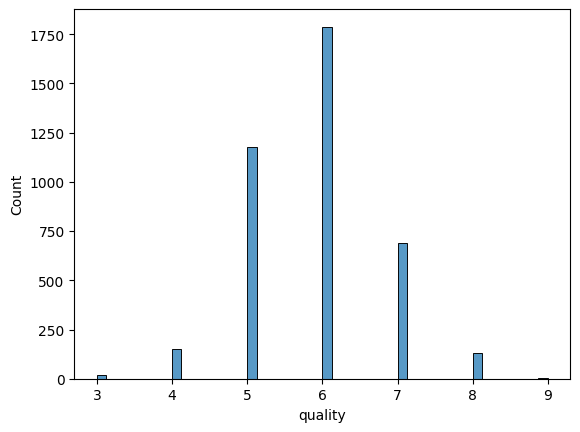

In [50]:
sns.histplot(df['quality'])
plt.show()

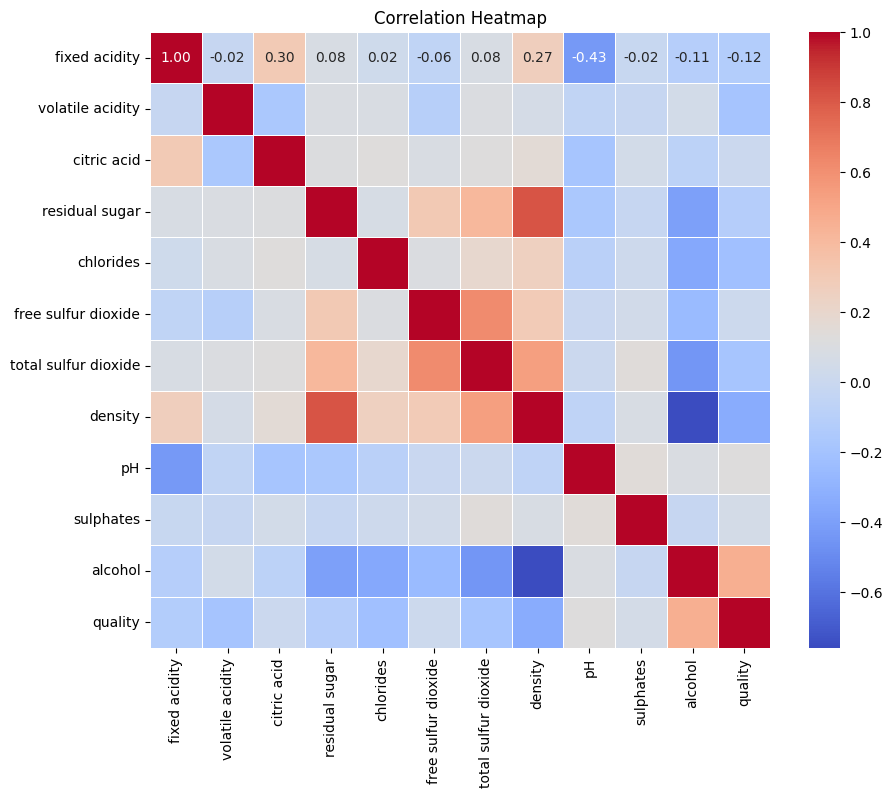

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",          
    cmap="coolwarm",
    linewidths=0.5      
)

plt.title("Correlation Heatmap")
plt.show()

In [52]:
col_list = list(df.columns)

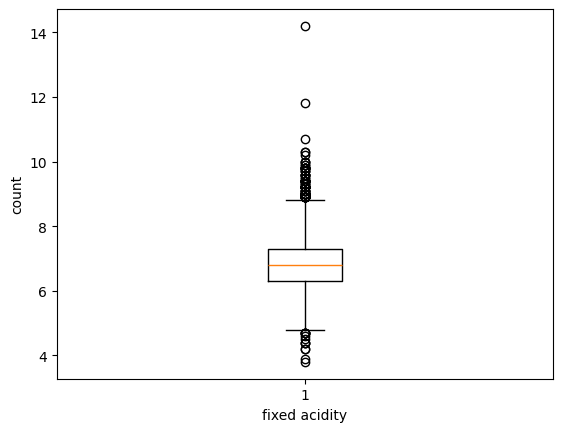

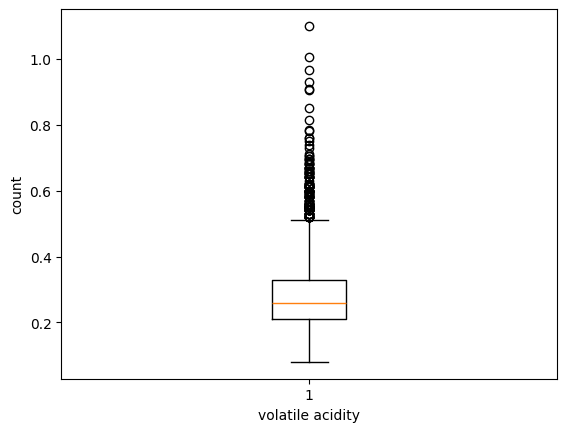

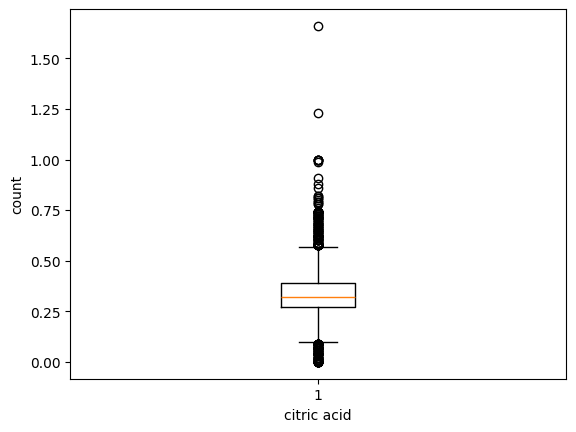

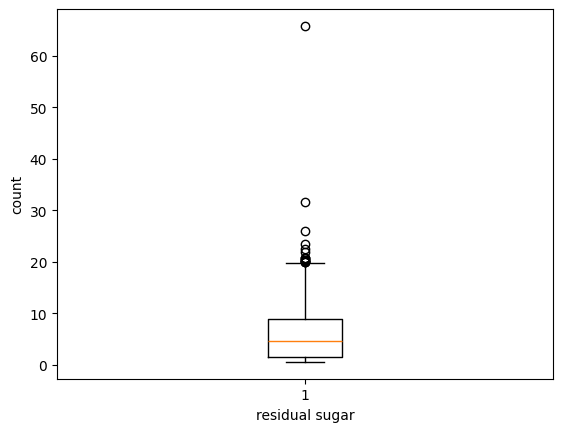

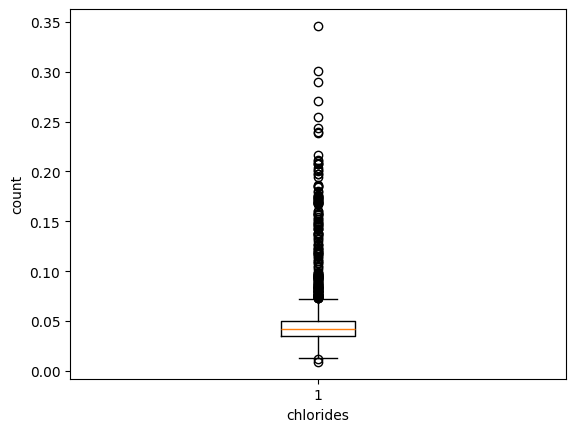

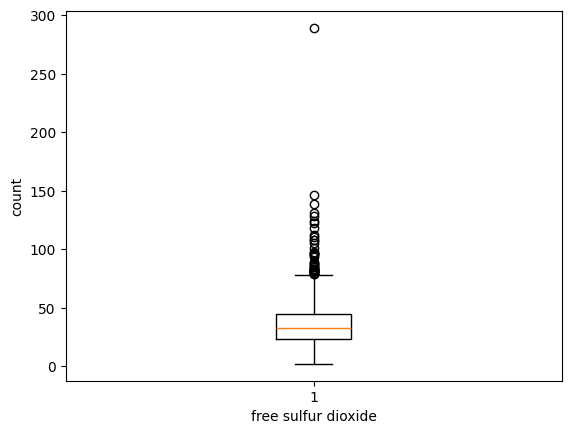

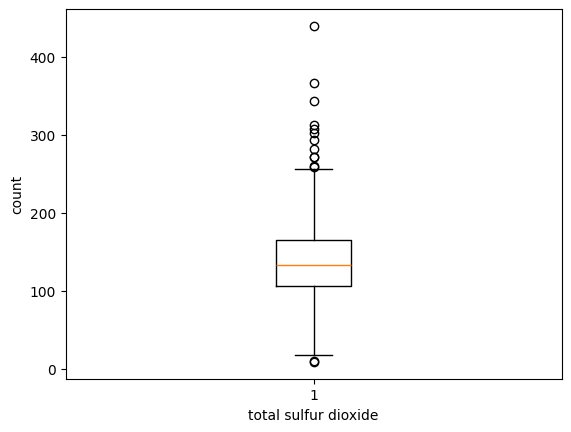

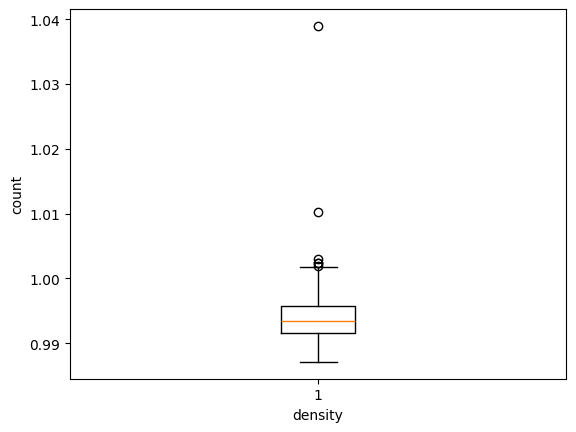

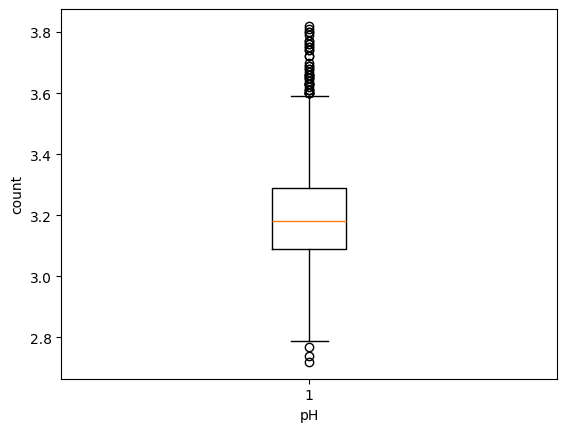

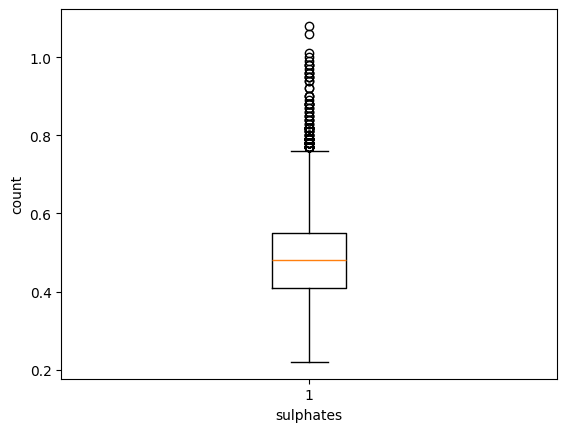

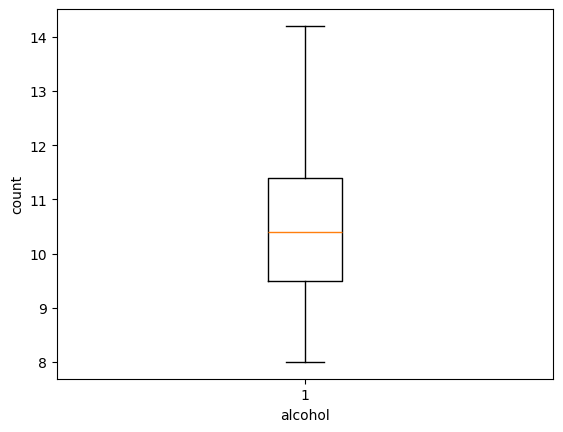

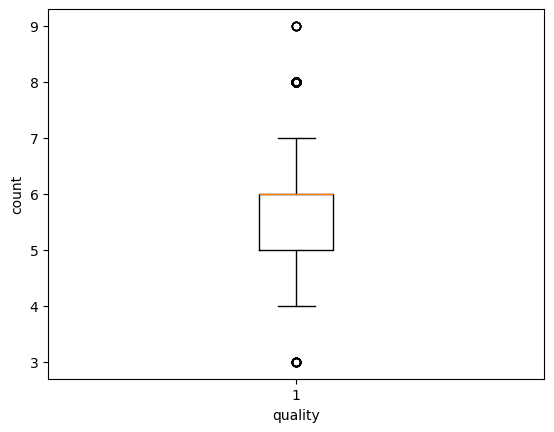

In [53]:
for x in col_list:
    if df[x].dtypes == 'object':
        continue
    plt.boxplot(df[x])
    plt.xlabel(x)
    plt.ylabel('count')
    plt.show()

In [54]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print(outliers)

fixed acidity           106
volatile acidity        133
citric acid             223
residual sugar           16
chlorides               178
free sulfur dioxide      44
total sulfur dioxide     14
density                   6
pH                       46
sulphates                96
alcohol                   0
quality                 156
dtype: int64


In [55]:
cols_to_treat = X.columns  # exclude target

for col in cols_to_treat:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

C:\Users\adity\AppData\Local\Temp\ipykernel_43676\2451647939.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower, upper)
C:\Users\adity\AppData\Local\Temp\ipykernel_43676\2451647939.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].clip(lower, upper)
C:\Users\adity\AppData\Local\Temp\ipykernel_43676\2451647939.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [58]:
from sklearn.metrics import * 
acc_lr = accuracy_score(y_pred_lr, y_test)*100
acc_lr

80.40370058873002

In [59]:
f1_lr = f1_score(y_pred_lr, y_test)*100
f1_lr

39.1644908616188

In [60]:
print(classification_report(y_pred_lr, y_test))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88      1052
           1       0.30      0.55      0.39       137

    accuracy                           0.80      1189
   macro avg       0.62      0.69      0.64      1189
weighted avg       0.86      0.80      0.83      1189



In [61]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [62]:
acc_dt = accuracy_score(y_pred_dt, y_test)*100
acc_dt

77.20773759461733

In [63]:
f1_dt = f1_score(y_pred_dt, y_test)*100
f1_dt

44.580777096114524

In [64]:
print(classification_report(y_pred_lr, y_test))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88      1052
           1       0.30      0.55      0.39       137

    accuracy                           0.80      1189
   macro avg       0.62      0.69      0.64      1189
weighted avg       0.86      0.80      0.83      1189



In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [66]:
acc_rf = accuracy_score(y_pred_rf, y_test)*100
acc_rf

81.83347350714887

In [67]:
f1_rf = f1_score(y_pred_rf, y_test)*100
f1_rf

44.329896907216494

In [68]:
print(classification_report(y_pred_rf, y_test))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      1047
           1       0.35      0.61      0.44       142

    accuracy                           0.82      1189
   macro avg       0.65      0.73      0.67      1189
weighted avg       0.87      0.82      0.84      1189

